<a href="https://colab.research.google.com/github/moralesalessandra29-crypto/LABORATORIO-DE-PDI/blob/main/P5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 5 - Tipos de Traslaciones de Imágenes**

* 2055762 Alondra María Cruz Castillo
* 2063509 Alessandra Morales Vázquez

In [1]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

*Ejercicio 1: Traslación básica de imagen*

---



Se cargará una imagen obtenida por medio de una Resonancia Magnética, la cual se leerá en escala de grises para no utilizar tanta memoria. Luego se le aplicará una traslación básica de 50 px en el eje 'x' y 30 px en el eje 'y'; comparando el resultado con la imagen original.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


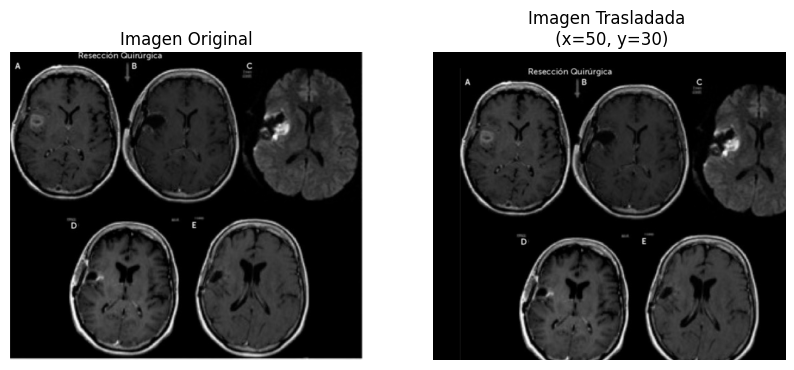

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Cargar imagen en escala de grises
ruta = "/content/drive/MyDrive/PDI/MRI.jpeg"

img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
ancho = img.shape[1]
alto = img.shape[0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Imagen Original')
plt.axis('off')

# Traslación básica (x=50, y=30)
x, y = 50, 30
M_tras = np.float32([[1, 0, x], [0, 1, y]])
img_tras = cv2.warpAffine(img, M_tras, (img.shape[1], img.shape[0]))
plt.subplot(1, 2, 2)
plt.imshow(img_tras, cmap='gray')
plt.title('Imagen Trasladada \n (x=50, y=30)')
plt.axis('off')

plt.show()

*Ejercicio 2: Traslación con valores decimales*

---



Se comparará el resultado de una traslación básica con el de una traslación con valores decimales. En este caso, la imagen original se trasladó 20.5 px en el eje 'x' y 15.5 px en el eje 'y'.

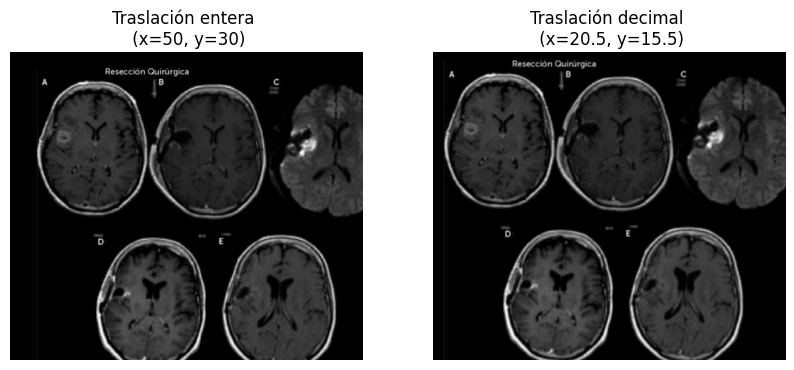

In [6]:
# Traslación con valores decimales (x=20.5, y=15.5)
x, y = 20.5, 15.5
M_tras = np.float32([[1, 0, x], [0, 1, y]])
img_trasdec = cv2.warpAffine(img, M_tras, (img.shape[1], img.shape[0]))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.imshow(img_trasdec, cmap='gray')
plt.title('Traslación decimal \n (x=20.5, y=15.5)')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(img_tras, cmap='gray')
plt.title('Traslación entera \n (x=50, y=30)')
plt.axis('off')

plt.show()

*Ejercicio 3: Traslación + Rotación*

---



Una vez que la imagen original fue trasladada, se le aplicó una rotación de 60° sobre su propio eje.

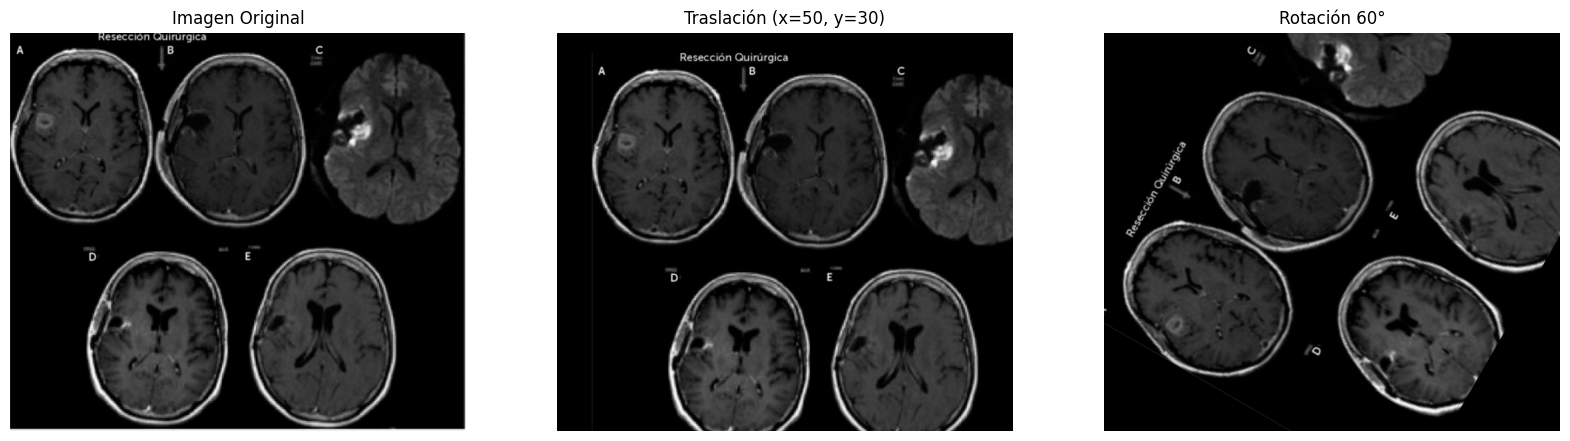

In [8]:
# Rotación de 60° después de una traslación
centro = (ancho // 2, alto // 2)
angulo = 60
escala = 1.0
M_rota = cv2.getRotationMatrix2D(centro, angulo, escala)
img_rot = cv2.warpAffine(img_tras, M_rota, (ancho, alto))
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 3)
plt.imshow(img_rot, cmap='gray')
plt.title('Rotación 60°')
plt.axis('off')

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_tras, cmap='gray')
plt.title('Traslación (x=50, y=30)')
plt.axis('off')

plt.show()

*Ejercicio 4: Traslación + Rotación + Escalado*

---



Después de su rotación, la imagen es dimensionada a diferentes escalas. Se puede comprobar que la imagen toma diferentes tamaños de acuerdo con la cantidad de píxeles que resulta después de cada escalado.

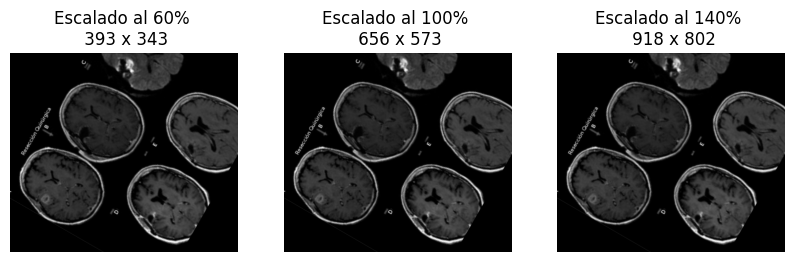

In [9]:
# Escalado después de una traslación y rotación
escala = 0.6       #Escalado al 60%
ancho_60 = int(img_rot.shape[1] * escala)
alto_60 = int(img_rot.shape[0] * escala)
img_esc60 = cv2.resize(img_rot, (ancho_60, alto_60), interpolation=cv2.INTER_LINEAR)
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_esc60, cmap='gray')
plt.title(f'Escalado al 60% \n {ancho_60} x {alto_60}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_rot, cmap='gray')
plt.title(f'Escalado al 100% \n {ancho} x {alto}')
plt.axis('off')

escala = 1.4       #Escalado al 140%
ancho_140 = int(img_rot.shape[1] * escala)
alto_140 = int(img_rot.shape[0] * escala)
img_esc140 = cv2.resize(img_rot, (ancho_140, alto_140), interpolation=cv2.INTER_LINEAR)
plt.subplot(1, 3, 3)
plt.imshow(img_esc140, cmap='gray')
plt.title(f'Escalado al 140% \n {ancho_140} x {alto_140}')
plt.axis('off')

plt.show()

*Ejercicio 5: Transformación Afín y Radial*

---



Primero a la imagen se le va a plicar una transformacion afin la cual mantiene las lineas rectas.

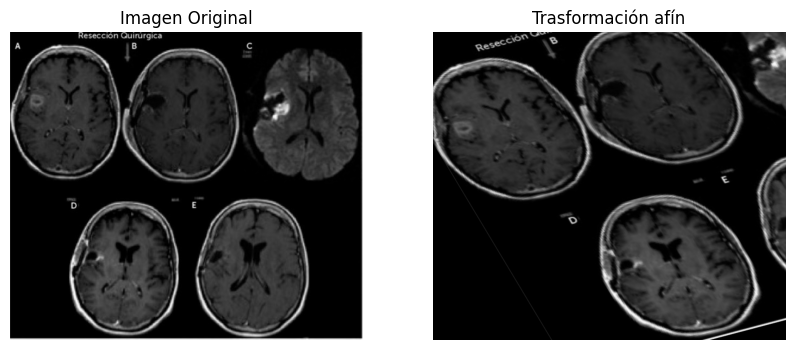

In [14]:
orig = np.float32([[50, 50], [200, 50], [50, 200]])

# Definir nuevos puntos transformados
transf = np.float32([[10, 100], [200, 50], [100, 250]])

# Obtener la matriz de transformación afín
M = cv2.getAffineTransform(orig, transf)

# Aplicar la transformación
filas, columnas = img.shape
imagen_transformada = cv2.warpAffine(img, M, (columnas, filas))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_transformada, cmap="gray")
plt.title("Trasformación afín")
plt.axis("off")

plt.show()

Luego se le aplicara una distorsion radial que deforma la imagen desde el centro hacia los bordes, a diferencia de la transformacion afin, en la distorsion las lineas rectas se vuelven curvas.

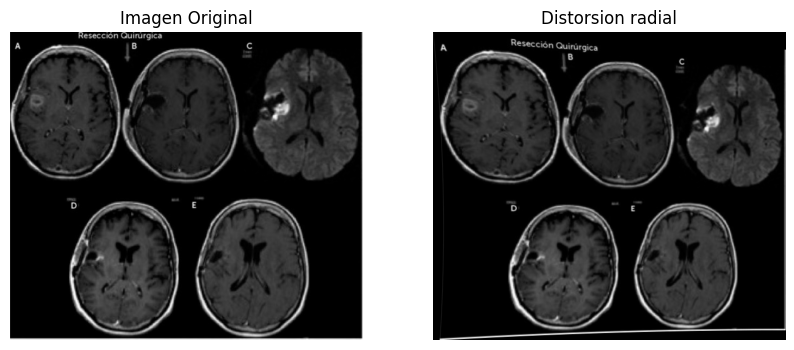

In [15]:
# Matriz de calibración de la cámara y coeficientes de distorsión
K = np.array([[1000, 0, 640], [0, 1000, 360], [0, 0, 1]])
dist_coef = np.array([-0.2, 0.05, 0, 0, 0])

# Corregir la distorsión radial
h, w = img.shape[:2]
new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist_coef, (w, h), 1, (w, h))
imagen_corregida = cv2.undistort(img, K, dist_coef, None, new_K)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen_corregida, cmap="gray")
plt.title("Distorsion radial")
plt.axis("off")

plt.show()